# **PREDICTING THE NEXT PRODUCT**

In [1]:
import matplotlib.pyplot as plt
import json
from collections import Counter

## **Загрузка данных**

In [2]:
sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))
print(f"Итоговое количество записей: {len(sessions)}")
print(f"Примеры записей: {sessions[0:5]}")

Итоговое количество записей: 2565
Примеры записей: [[380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293], [53, 54, 53, 65, 53, 335, 286, 335], [54, 397, 398, 294, 223, 293, 233], [335, 54, 335, 221, 41, 247, 380, 114, 43, 111, 257, 335, 54, 62, 387, 362, 387], [252, 301, 387, 212, 246, 61, 175, 392, 370, 233, 92]]


## **Анализ данных**

In [3]:
goods = Counter()
for session in sessions:
    goods.update(session)

print(f"Количество уникальных товаров: {len(goods)}")

Количество уникальных товаров: 400


#### Посмотрим как распределены данные

Распределение частот товаров: для удобства разделим на 2 графика по диапозонам.

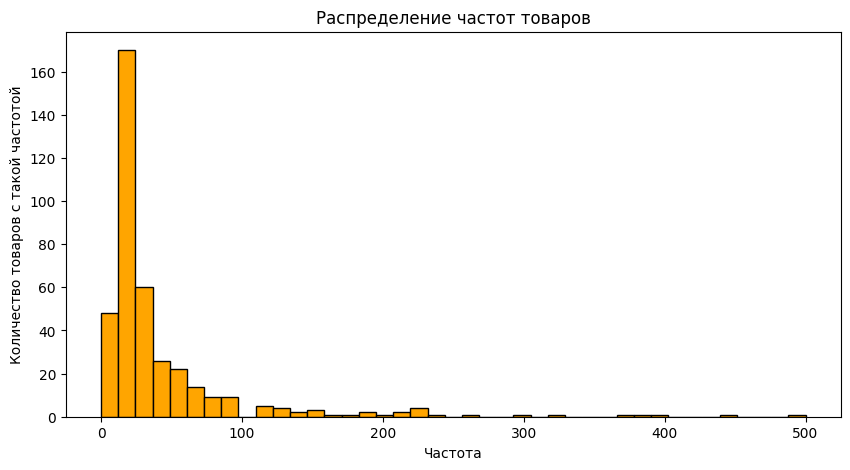

In [4]:
frequencies = list(goods.values())
plt.figure(figsize=(10, 5))
plt.hist(frequencies, bins='auto', range = (0,500), color = 'orange', edgecolor='black')
plt.xlabel('Частота')
plt.ylabel('Количество товаров с такой частотой')
plt.title('Распределение частот товаров')
plt.show()


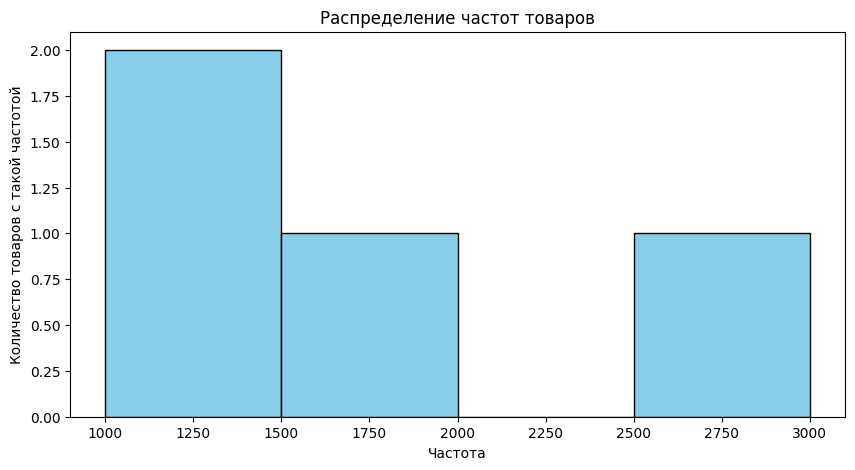

In [5]:
frequencies = list(goods.values())
plt.figure(figsize=(10, 5))
plt.hist(frequencies, bins='auto', range = (1000,3000), color = 'skyblue', edgecolor='black')
plt.xlabel('Частота')
plt.ylabel('Количество товаров с такой частотой')
plt.title('Распределение частот товаров')
plt.show()

**Вывод**: наибольшее число товаров встречается от 0 до 100 раз, частоты имеют экспоненциальное распределение.

In [6]:
top = goods.most_common(10)  
top

[(54, 2914),
 (335, 1691),
 (53, 1223),
 (114, 1067),
 (260, 833),
 (293, 736),
 (380, 571),
 (212, 510),
 (329, 492),
 (257, 450)]

In [7]:
least = goods.most_common()[-10:]
least

[(220, 8),
 (274, 8),
 (172, 8),
 (206, 8),
 (291, 7),
 (117, 7),
 (326, 6),
 (118, 6),
 (184, 5),
 (305, 5)]

In [8]:
import statistics

frequencies = list(goods.values())

mean_freq = statistics.mean(frequencies)
median_freq = statistics.median(frequencies)
mode_freq = statistics.mode(frequencies)
print(f"Средняя частота: {mean_freq:.1f}")
print(f"Медианная частота: {median_freq:.0f}")
print(f"Мода: {mode_freq}")

Средняя частота: 67.1
Медианная частота: 22
Мода: 20


#### Рассмотрим длины записей

In [9]:
lens = []
for session in sessions:
    lens.append(len(session))
lens[0:10]

[17, 8, 7, 17, 11, 5, 19, 9, 4, 10]

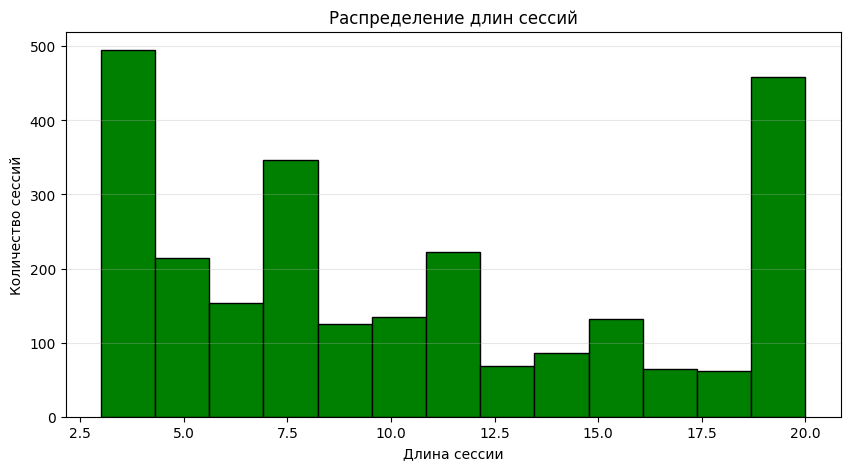

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(lens, bins='auto', edgecolor='black', color='green')
plt.xlabel('Длина сессии')
plt.ylabel('Количество сессий')
plt.title('Распределение длин сессий')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [11]:
mean_len = statistics.mean(lens)
median_len = statistics.median(lens)
mode_len = statistics.mode(lens)
print(f"Средняя длина сессии: {mean_len:.1f}")
print(f"Медианная длина сессии: {median_len:.0f}")
print(f"Мода: {mode_len:.0f}")

Средняя длина сессии: 10.5
Медианная длина сессии: 9
Мода: 20


**Вывод**: распределение скошено вправо, сессии в основном либо слишком короткие (3), либо слишком длинные (20). Достаточно маленькое число сессий  имеют среднюю длину. Большинство сессий имеют длину 20.

In [12]:
len_9 = sum(1 for l in lens if l == 9)
len_3 = sum(1 for l in lens if l == 3)
len_20 = sum(1 for l in lens if l == 20)
print(f"Сколько конкретно встречаются длины сессий {len_9}, {len_3}, {len_20}")

Сколько конкретно встречаются длины сессий 125, 249, 410


#### Как часто встречаются повторы в рамках одной сессии и что это за товары?

In [13]:
total_repeats = 0
sessions_with_repeats = 0

for session in sessions:
    counts = Counter(session)
    repeats_in_session = sum(c - 1 for c in counts.values() if c > 1)
    if repeats_in_session > 0:
        total_repeats += repeats_in_session
        sessions_with_repeats += 1

print(f"Всего повторов: {total_repeats}")
print(f"Сессий с повторами: {sessions_with_repeats} из {len(sessions)} "
      f"({sessions_with_repeats/len(sessions)*100:.1f}%)")


Всего повторов: 3780
Сессий с повторами: 1552 из 2565 (60.5%)


#### Заметим, что процент сессий с повторами достаточно значимый, рассмотрим этот вопрос более подробно.

In [14]:
from collections import defaultdict
repeat_stats = defaultdict(lambda: {
    'total_repeats': 0,
    'sessions_count': 0,
    'max_in_session': 0,
    'frequencies': []
})
for session in sessions:
    counts = Counter(session)
    for item_id, count in counts.items():
        if count > 1:
            repeats = count - 1  
            stats = repeat_stats[item_id]
            stats['total_repeats'] += repeats
            stats['sessions_count'] += 1
            stats['frequencies'].append(count)
            if count > stats['max_in_session']:
                stats['max_in_session'] = count
sorted_by_repeats = sorted(repeat_stats.items(),
                           key=lambda x: x[1]['total_repeats'],
                           reverse=True)
print(f"Товаров, которые хоть раз повторились в сессии: {len(repeat_stats)}")
print("\nТоп-10 лучших товаров по общему числу повторов:")
for item_id, stats in sorted_by_repeats[:10]:
    print(f"  Товар {item_id}: повторы = {stats['total_repeats']}, "
          f"число сессий = {stats['sessions_count']}, "
          f"макс частота в сессии = {stats['max_in_session']}, "
          f"примеры частот = {stats['frequencies'][:5]}")
sorted_by_sessions = sorted(repeat_stats.items(),
                            key=lambda x: x[1]['sessions_count'],
                            reverse=True)




Товаров, которые хоть раз повторились в сессии: 135

Топ-10 лучших товаров по общему числу повторов:
  Товар 54: повторы = 1230, число сессий = 794, макс частота в сессии = 7, примеры частот = [2, 2, 2, 2, 2]
  Товар 335: повторы = 580, число сессий = 399, макс частота в сессии = 5, примеры частот = [2, 3, 2, 2, 2]
  Товар 114: повторы = 286, число сессий = 213, макс частота в сессии = 6, примеры частот = [2, 3, 2, 2, 3]
  Товар 53: повторы = 283, число сессий = 227, макс частота в сессии = 5, примеры частот = [3, 2, 3, 2, 2]
  Товар 260: повторы = 211, число сессий = 169, макс частота в сессии = 5, примеры частот = [2, 2, 2, 2, 2]
  Товар 293: повторы = 141, число сессий = 116, макс частота в сессии = 4, примеры частот = [3, 2, 2, 3, 2]
  Товар 212: повторы = 96, число сессий = 74, макс частота в сессии = 5, примеры частот = [2, 3, 2, 2, 2]
  Товар 380: повторы = 85, число сессий = 70, макс частота в сессии = 4, примеры частот = [3, 3, 2, 2, 2]
  Товар 329: повторы = 63, число сессий 

In [15]:
items_with_1_repeat = [
    (item_id, stats) 
    for item_id, stats in repeat_stats.items() 
    if stats['total_repeats'] == 1
]

total_repeat_items = len(repeat_stats)  
count_1_repeat = len(items_with_1_repeat)

print(f"Всего товаров с повторами: {total_repeat_items}")
print(f"Из них повторяются только один раз: {count_1_repeat} "
      f"({count_1_repeat/total_repeat_items*100:.1f}%)")


Всего товаров с повторами: 135
Из них повторяются только один раз: 57 (42.2%)


**Вывод**: 57 товаров встречаются повторно только один раз, это больше похоже на случайное совпадение, чем на паттерн в данных. Однако 78 товаров из 400 повторяются в рамках одной записи более 1 раза, что уже нельзя не учитывать при построении модели. Среди самых популярных товаров артикулы: 54, 335, 114, 53, 260 и т.д., которые встречаются в одной сессии от 5 до 7 раз. Стоит отметить, что 60,5 % записей имеют повторы внутри, что говорит об их статистической значимости.

### **Ключевые инсайды анализа данных**

**О данных в целом**: 2565 сессий, 400 уникальных товаров, средняя длина сессии 10.5.

**О длинах сессий**: бимодальное распределение, имеющее пик на 3-4 товарах внутри сессии и пик на 20 товарах. Причем длина 20 встречается чаще: 410 сессий из 2565 или 16%.

**О частотах товаров**: экспоненциальное распределение, несколько товаров доминируют, большинство редкие. 

**О повторах**: 60.5% сессий содержат повторы. Повторы сконцентрированы в малой группе товаров, а именно топ-5 по повторам товаров дают 2593 из 3780 повторов (68%). Товар 54 один даёт 32% всех повторов. Интересно, что в среднем одна сессия содержит приблизительно 2,44 повтора.

## **SPLIT данных**

In [16]:
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets

In [17]:
train_sessions, test_targets = train_test_split(sessions)
print(train_sessions[:10])
print(test_targets[:10])
      

[[380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341], [53, 54, 53, 65, 53, 335, 286], [54, 397, 398, 294, 223, 293], [335, 54, 335, 221, 41, 247, 380, 114, 43, 111, 257, 335, 54, 62, 387, 362], [252, 301, 387, 212, 246, 61, 175, 392, 370, 233], [53, 398, 104, 148], [260, 149, 260, 92, 13, 385, 156, 65, 104, 54, 329, 54, 394, 76, 189, 287, 5, 11], [257, 62, 362, 212, 15, 349, 247, 397], [335, 396, 156], [53, 114, 380, 46, 360, 85, 42, 54, 53]]
[293, 335, 233, 387, 92, 114, 114, 260, 394, 277]


Случайное разбиение в данном случае не подходит, потому что данные упорядочены по времени. Здесь важна именно последовательность товаров, паттерны, например почему из n товара следует m товар, как связаны они между собой? Рандомное разбиение сломает логику переходов между товарами, например у нас есть запись n -> m -> p -> s и при выборе например n или m как цели модель будет обучаться на следующих данных, не предсказывая результат, а заведомо зная его. 

## **ГРАФ ПЕРЕХОДОВ**

**Идея**: запомнить паттерны переходов i -> j и на основе тренировочных данных и посчитать вероятность как P(j|i) = count(i→j) / count(i→*), где count(i→*) - сколько раз товар i был левым в любой паре. Повторы считать будем как есть, переход i->i - это петля в графе. Редкие переходы обрабатываются при помощи сглаживания Лапласса: P(j|i) = (count(i→j) + 1) / (total_after[i] + 1 * N), где N - число уникальных товаров. 

In [25]:
def build_transition_graph(train_sessions):
    transition_counts = defaultdict(lambda: defaultdict(int))
    for session in train_sessions:
        for k in range(0,len(session)-1):  
            i = session[k]
            j = session[k+1]
            transition_counts[i][j] += 1
    
    return transition_counts


def calculate_probabilities(transition_counts, all_items):
    n_items = len(all_items)
    probabilities = {}
    for i, neighbors in transition_counts.items():
        total = sum(neighbors.values())  
        probabilities[i] = {}
        for j in all_items:
            raw_count = neighbors.get(j, 0)
            probabilities[i][j] = (raw_count + 1) / (total + len(all_items))
    
    return probabilities


def recommend(last_item, probabilities, popular_fallback, k=10):
    if last_item not in probabilities:
        return popular_fallback

    scores = probabilities[last_item]
    top_k = sorted(scores.keys(), key=lambda item: scores[item], reverse=True)
    return [item for item in top_k if item != last_item][:k]

In [26]:
all_items = list(goods.keys())
transition_counts = build_transition_graph(train_sessions)
train_goods = Counter()
for session in train_sessions:
    train_goods.update(session)

popular_fallback = [item for item, count in train_goods.most_common(10)]
probabilities = calculate_probabilities(transition_counts, all_items)

## **Оценка**

In [27]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

## **Тестирование рекомендательной модели**

In [28]:
all_recommendations = []
for session in train_sessions:
    last_item = session[-1]
    recs = recommend(last_item, probabilities, popular_fallback)
    all_recommendations.append(recs)

score = hit_at_k(all_recommendations, test_targets)
print(f"Hit@10 модели: {score:.3f}")
baseline_recs = [popular_fallback for _ in train_sessions]
baseline_score = hit_at_k(baseline_recs, test_targets)
print(f"Hit@10 бейзлайна: {baseline_score:.3f}")

Hit@10 модели: 0.519
Hit@10 бейзлайна: 0.384


In [29]:
all_counts = []
for i, neighbors in transition_counts.items():
    for j, count in neighbors.items():
        all_counts.append(count)

print(f"Всего уникальных переходов: {len(all_counts)}")
print(f"Переходов с count=1: {sum(1 for c in all_counts if c == 1)}")
print(f"Переходов с count=2: {sum(1 for c in all_counts if c == 2)}")
print(f"Переходов с count=2: {sum(1 for c in all_counts if c > 2)}")
print(f"Медиана: {sorted(all_counts)[len(all_counts)//2]}")

Всего уникальных переходов: 8620
Переходов с count=1: 5903
Переходов с count=2: 1224
Переходов с count=2: 1493
Медиана: 1


# **ИТОГ**

Модель, основанная на графе переходов превосходит бейзлайн на 14 процентов, поскольку модель учитывает контекст предыдущих товаров и имеющиеся паттерны переходов. Однако Hit@10 всё ещё достаточно низкий, поскольку большое количество коротких сессий из 3 элементов имеют недостаточно данных для более точного ответа. Высокая доля повторяющихся элементов так же сильно влияет на результат, поскольку тяжело определить редкие переходы и товары. 